# 01 数据下载、对齐与清洗

本 Notebook 完成以下任务：

1. 下载美联储政策利率数据与全球股指价格数据
2. 构建加息/降息事件表
3. 计算各市场日对数收益率
4. 处理节假日与交易日错位问题，生成事件日映射表
5. 保存原始数据和清洗后数据

In [1]:
from pathlib import Path

import sys

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns



PROJECT_DIR = Path.cwd()

if PROJECT_DIR.name != 'T2_FED_world_stock_market':

    PROJECT_DIR = Path.cwd() / 'homework' / 'Topics_01' / 'T2_FED_world_stock_market' if (Path.cwd() / 'homework' / 'Topics_01' / 'T2_FED_world_stock_market').exists() else Path.cwd()

CODE_DIR = PROJECT_DIR / 'code'

if str(CODE_DIR) not in sys.path:

    sys.path.append(str(CODE_DIR))



from data_utils import (

    MARKET_CONFIG,

    download_fed_rate,

    build_fed_events,

    download_global_market_prices,

    compute_log_returns,

    align_events_for_all_markets,

    summarize_event_counts,

)



plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']

plt.rcParams['axes.unicode_minus'] = False

sns.set_style('whitegrid')

pd.set_option('display.max_columns', None)



DATA_RAW = PROJECT_DIR / 'data_raw'

DATA_CLEAN = PROJECT_DIR / 'data_clean'

OUTPUT_DIR = PROJECT_DIR / 'output'



START_DATE = '2000-01-01'

print('项目目录:', PROJECT_DIR)

print('样本起点:', START_DATE)


项目目录: d:\github_lianxh\dsfin\homework\Topics_01\T2_FED_world_stock_market
样本起点: 2000-01-01


## 1. 下载美联储利率数据

In [2]:
fed_rate_raw = download_fed_rate(start_date=START_DATE)
fed_events = build_fed_events(fed_rate_raw)
event_summary = summarize_event_counts(fed_events)

print('利率原始记录数:', len(fed_rate_raw))
print('实质性调整事件数:', len(fed_events))
display(event_summary)
display(fed_events.head(10))

利率原始记录数: 6308
实质性调整事件数: 31


,type,count,avg_change_bp,min_date,max_date
0,cut,11,-36.363636,2019-08-01,2025-12-11
1,hike,20,37.500000,2015-12-16,2023-07-27


,date,rate_after,rate_before,change_bp,type,year,event_id,type_cn
0,2015-12-16,0.50,0.25,25,hike,2015,2557,加息
1,2016-12-14,0.75,0.50,25,hike,2016,2921,加息
2,2017-03-16,1.00,0.75,25,hike,2017,3013,加息
3,2017-06-15,1.25,1.00,25,hike,2017,3104,加息
4,2017-12-14,1.50,1.25,25,hike,2017,3286,加息
5,2018-03-22,1.75,1.50,25,hike,2018,3384,加息
6,2018-06-14,2.00,1.75,25,hike,2018,3468,加息
7,2018-09-27,2.25,2.00,25,hike,2018,3573,加息
8,2018-12-20,2.50,2.25,25,hike,2018,3657,加息
9,2019-08-01,2.25,2.50,-25,cut,2019,3881,降息


C:\Users\Administrator\AppData\Local\Temp\ipykernel_23592\3105092294.py:11: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23592\3105092294.py:11: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23592\3105092294.py:11: UserWarning: Glyph 21033 (\N{CJK UNIFIED IDEOGRAPH-5229}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23592\3105092294.py:11: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23592\3105092294.py:11: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23592\3105092294.py:11: UserWarni

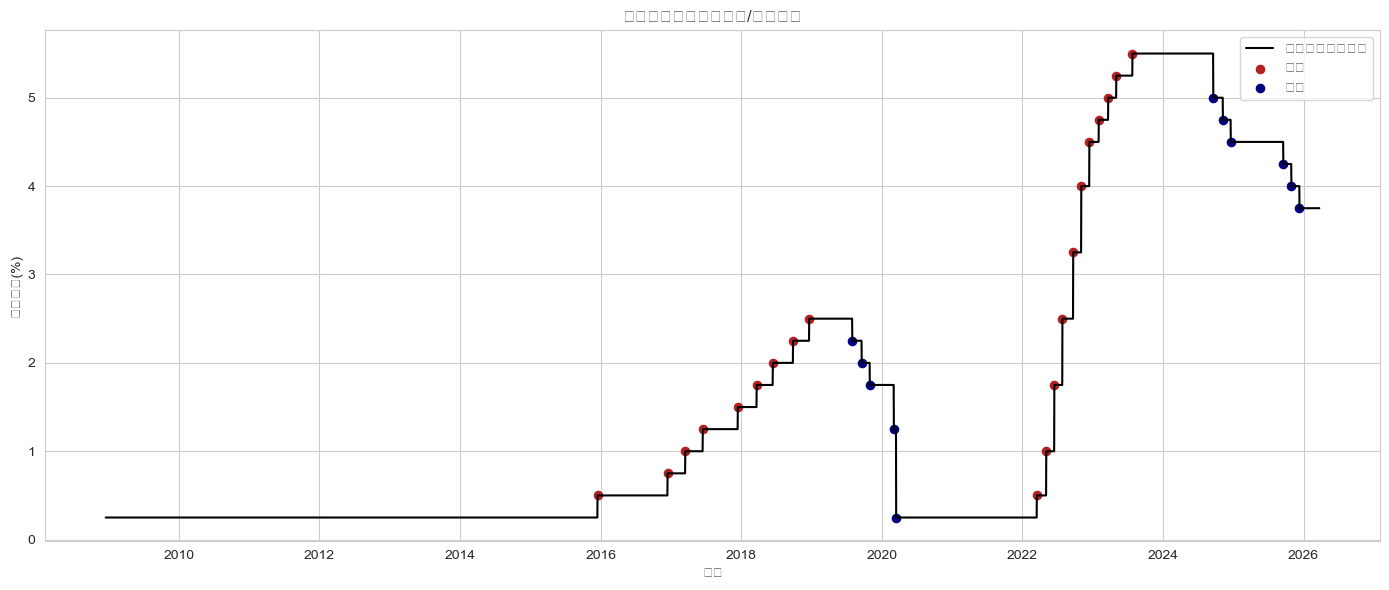

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(fed_rate_raw['date'], fed_rate_raw['rate_after'], color='black', linewidth=1.5, label='联邦基金目标利率')
hike_df = fed_events[fed_events['type'] == 'hike']
cut_df = fed_events[fed_events['type'] == 'cut']
ax.scatter(hike_df['date'], hike_df['rate_after'], color='firebrick', s=35, label='加息')
ax.scatter(cut_df['date'], cut_df['rate_after'], color='navy', s=35, label='降息')
ax.set_title('美联储政策利率与加息/降息事件')
ax.set_xlabel('日期')
ax.set_ylabel('利率水平(%)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fed_rate_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. 下载全球股指价格

In [4]:
global_prices = download_global_market_prices(start_date=START_DATE)
global_returns = compute_log_returns(global_prices)

print('价格数据维度:', global_prices.shape)
print('收益率数据维度:', global_returns.shape)
display(global_prices.head())
display(global_returns.describe().T)

  0%|          | 0/17 [00:00<?, ?it/s]

ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

In [5]:
market_labels = {key: cfg['label'] for key, cfg in MARKET_CONFIG.items()}
cum_nav = (1 + global_returns.fillna(0)).cumprod()
cum_nav = cum_nav.rename(columns=market_labels)

plt.figure(figsize=(14, 7))
for column in cum_nav.columns:
    plt.plot(cum_nav.index, cum_nav[column], label=column, linewidth=1.4)
plt.title('全球主要股指累计净值走势')
plt.xlabel('日期')
plt.ylabel('累计净值')
plt.legend(ncol=3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'global_index_nav.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'global_returns' is not defined

## 3. 事件日映射与对齐

In [ ]:
aligned_events = align_events_for_all_markets(fed_events, global_returns)

mapping_columns = ['date', 'change_bp', 'type'] + [f'{key}_event_date' for key in MARKET_CONFIG]
display(aligned_events[mapping_columns].head(10))

mapping_gap_summary = []
for key in MARKET_CONFIG:
    gap = (pd.to_datetime(aligned_events[f'{key}_event_date']) - pd.to_datetime(aligned_events['date'])).dt.days
    mapping_gap_summary.append({
        'market_key': key,
        'market_label': MARKET_CONFIG[key]['label'],
        'avg_mapping_gap_days': gap.mean(),
        'max_mapping_gap_days': gap.max(),
        'min_mapping_gap_days': gap.min(),
    })
mapping_gap_summary = pd.DataFrame(mapping_gap_summary)
display(mapping_gap_summary)

## 4. 保存数据

In [ ]:
fed_rate_raw.to_csv(DATA_RAW / 'fed_rate_raw.csv', index=False)
global_prices.to_csv(DATA_RAW / 'global_index_prices.csv')
fed_events.to_csv(DATA_CLEAN / 'fed_events.csv', index=False)
aligned_events.to_csv(DATA_CLEAN / 'fed_events_aligned.csv', index=False)
global_returns.to_csv(DATA_CLEAN / 'global_index_returns.csv')
event_summary.to_csv(OUTPUT_DIR / 'fed_event_summary.csv', index=False)
mapping_gap_summary.to_csv(OUTPUT_DIR / 'event_date_mapping_summary.csv', index=False)
print('数据保存完成')

## 5. 文字结论

- 美联储政策利率序列已经被转换为结构化事件表，可直接用于后续事件研究和回归分析。
- 各市场的交易日并不完全同步，因此事件日收益率采用“决议日及其后首个可交易日”映射。
- 下一步将在事件窗口内计算异常收益率和累计异常收益率，并比较加息与降息的市场反应差异。